## LOAD DATA & MODELS
#### adapted from training_models.py

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum, when, avg, expr, log1p, expm1, abs, lit,desc
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder,FeatureHasher
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.regression import RandomForestRegressionModel, LinearRegressionModel, GBTRegressionModel
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder, TrainValidationSplit
from pyspark.sql.types import FloatType, IntegerType
import matplotlib.pyplot as plt
import os
# from dotenv import load_dotenv


In [6]:
spark=SparkSession.builder.appName('Inspecting_healthcare').getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
base_path='dataSets/final_data'

url=base_path+"/final_data.csv" 
data=spark.read.option('header','true').option('inferSchema','true').csv(url)

data=data.na.drop()

total_cat=['HCPCS_Cd', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
num_cols=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
low_cardy=[]
high_cardy=[]

for column in total_cat:
    
    data=data.withColumn(column,col(column).cast('string')) #casting to treat as category 

    dis_val=data.select(column).distinct().count()

    if dis_val<60:
        low_cardy.append(column)
    else:
        high_cardy.append(column)

    print(f'Column: {column} number of unique values: {dis_val}')

unique_count = data.groupBy("HCPCS_Cd").count()


common_codes = (
    unique_count
    .filter(col("count") > 50)
    .select("HCPCS_Cd")
)

common_rows = (
    data.join(common_codes, on="HCPCS_Cd", how="left_semi")
)

rare_rows = (
    data.join(common_codes, on="HCPCS_Cd", how="left_anti")
        .withColumn("HCPCS_Cd", lit("RARE").cast("string"))
)

# force identical schema/order on both sides
common_rows = common_rows.select(*data.columns)
rare_rows = rare_rows.select(*data.columns)

data = common_rows.unionByName(rare_rows)

X=data.sample(fraction=0.05,seed=42)

for column in num_cols:
    X=X.withColumn(column,log1p(col(column)))

#Now the target
X=X.withColumn('Avg_Sbmtd_Chrg',log1p(col('Avg_Sbmtd_Chrg')))

X_train,X_test=X.randomSplit([0.8, 0.2], seed=42)

Column: HCPCS_Cd number of unique values: 9966


Column: HCPCS_Drug_Ind number of unique values: 2


Column: Place_Of_Srvc number of unique values: 2


Column: Rndrng_Prvdr_Geo_Cd number of unique values: 56


Column: Year number of unique values: 11


In [10]:
# #Defining Columns
# total_cat=['HCPCS_Cd', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
# num_cols=['Tot_Rndrng_Prvdrs','Tot_Benes','Tot_Srvcs','Tot_Bene_Day_Srvcs']
# low_cardy=[]
# high_cardy=[]

# Low cardinality columns: ['HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Rndrng_Prvdr_Geo_Cd', 'Year']
# High cardinality columns: ['HCPCS_Cd']

#indexing
string_indexer=StringIndexer(inputCols=total_cat[1:],
                             outputCols=[f'{c}_idx' for c in total_cat[1:]],#skipping HCPCS_Cd
                             handleInvalid='keep')

ohencoder=OneHotEncoder(inputCols=[f'{c}_idx' for c in low_cardy],
                        outputCols=[f'{c}_ohe' for c in low_cardy],
                        handleInvalid='keep'
)


# Hash HCPCS_Cd into a fixed-size vector
hcpcs_hasher = FeatureHasher(
    inputCols=["HCPCS_Cd"],
    outputCol='HCPCS_Cd_hash',
    numFeatures=1024
)
#6.4 categories per bucket, not bad

#vectorize to scale
scale_assembler=VectorAssembler(inputCols=num_cols,
                                outputCol='num_features')

#scaling #check if log transfor need to be used for the other columns not just the target!!!!!
scaler=StandardScaler(inputCol='num_features',
                      outputCol='scaled_num_features')
#vectorizing everything
assembler=VectorAssembler(
    inputCols=['HCPCS_Cd_hash']+
    [f'{c}_ohe' for c in low_cardy]+
    ['scaled_num_features'],
 outputCol='Features_Col'
)

feature_pipeline = Pipeline(stages=[
    string_indexer,
    ohencoder,
    hcpcs_hasher,
    scale_assembler,
    scaler,
    assembler
])

feature_model = feature_pipeline.fit(X_train)

train_features = feature_model.transform(X_train).cache()
test_features  = feature_model.transform(X_test).cache()

train_features.count()

112031

In [7]:
MODEL_MAP = {
    "RandomForestRegressor": RandomForestRegressionModel,
    "LinearRegression": LinearRegressionModel,
    "GBTRegressor": GBTRegressionModel
}

def spark_model_faster(model, X_test, model_path):
    model_name = model.__class__.__name__ #very useful to get the model name

    if os.path.exists(model_path):
        print("Loading existing model...")

        if model_name not in MODEL_MAP:
            raise ValueError(f"No loader defined for {model_name}")

        model_class = MODEL_MAP[model_name]
        fitted_model = model_class.load(model_path)

    else:
        raise ValueError(f"No trained model found for {model_name}") 

    # Predict
    test_predictions = fitted_model.transform(X_test)

    return fitted_model, test_predictions

## ANALYSIS

In [32]:
import os
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

fips_map={
    '1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE',
    '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
    '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA',
    '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV',
    '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH',
    '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN',
    '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
    '56': 'WY', '72': 'PR'
}

def map_states(df, col_name='Rndrng_Prvdr_Geo_Cd'):
    df['State_Label']=df[col_name].astype(str).map(fips_map).fillna(df[col_name].astype(str))
    return df

def plot_geographic_anomalies(preds, model_name="Model"):
    geo_anomalies=preds.groupBy("Rndrng_Prvdr_Geo_Cd").agg(
        F.mean("Actual_Dollar_Charge").alias("Avg_State_Charge"),
        F.count("*").alias("Total_Procedures")
    ).filter(F.col("Total_Procedures") > 100)

    pandas_geo=geo_anomalies.orderBy(F.desc("Avg_State_Charge")).toPandas()
    pandas_geo=map_states(pandas_geo)

    plt.figure(figsize=(12, 6))
    pandas_geo.head(15).plot(kind='bar', x="State_Label", y="Avg_State_Charge", color="firebrick", legend=False, ax=plt.gca())
    plt.title(f"[{model_name}] Geographic Anomalies: top 15 regions with largest avg differences")
    plt.ylabel("Average Difference ($)")
    plt.xlabel("State")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_geographic_anomalies.png")
    plt.show()

def plot_error_analysis(preds, model_name="Model"):
    error_analysis=preds.groupBy("Rndrng_Prvdr_Geo_Cd").agg(
        F.mean("Abs_Dollar_Error").alias("Mean_Absolute_Error_Dollars"),
        F.mean("Dollar_Error").alias("Directional_Bias") 
    ).filter(F.count("*") > 100)

    pandas_errors=error_analysis.orderBy(F.desc("Mean_Absolute_Error_Dollars")).toPandas()
    pandas_errors=map_states(pandas_errors)

    plt.figure(figsize=(12, 6))
    pandas_errors.head(15).plot(kind='bar', x="State_Label", y="Mean_Absolute_Error_Dollars", color="steelblue", legend=False, ax=plt.gca())
    plt.title(f"[{model_name}] Error Analysis: regions with the largest prediction errors")
    plt.ylabel("Average Error ($)")
    plt.xlabel("State")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_error_analysis.png")
    plt.show()
    
    return error_analysis

def plot_directional_bias(error_analysis, model_name="Model"):
    pandas_bias=error_analysis.orderBy("Directional_Bias").toPandas()
    pandas_bias=map_states(pandas_bias)

    plt.figure(figsize=(14, 6))
    colors=['firebrick' if x < 0 else 'seagreen' for x in pandas_bias['Directional_Bias']]
    
    pandas_bias.plot(kind='bar', x="State_Label", y="Directional_Bias", color=colors, legend=False, ax=plt.gca())
    plt.title(f"[{model_name}] Directional Bias: over or under-predicting by state?")
    plt.ylabel("Average Bias ($)")
    plt.axhline(0, color='black', linewidth=1.5)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_directional_bias.png")
    plt.show()

def plot_error_distribution(preds, error_analysis, model_name="Model"):
    pandas_errors=error_analysis.orderBy(F.desc("Mean_Absolute_Error_Dollars")).toPandas()
    top_5_fips=pandas_errors.head(5)['Rndrng_Prvdr_Geo_Cd'].tolist()

    worst_states_data=preds.filter(F.col("Rndrng_Prvdr_Geo_Cd").isin(top_5_fips)).select("Rndrng_Prvdr_Geo_Cd", "Dollar_Error").sample(fraction=0.1, seed=42).toPandas()

    worst_states_data=map_states(worst_states_data)

    plt.figure(figsize=(10, 6))
    worst_states_data.boxplot(column='Dollar_Error', by='State_Label', ax=plt.gca(), grid=False, patch_artist=True)
    plt.title(f"[{model_name}] dist. of errors for top 5 worst states")
    plt.suptitle("") 
    plt.ylabel("Prediction Error ($)")
    plt.xlabel("State")
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_error_distribution.png")
    plt.show()

def plot_actual_vs_predicted(preds, model_name="Model"):
    scatter_data=preds.select("Actual_Dollar_Charge", "prediction_original").sample(fraction=0.1, seed=42).limit(3000).toPandas()

    plt.figure(figsize=(9, 9))
    plt.scatter(scatter_data["Actual_Dollar_Charge"], scatter_data["prediction_original"], alpha=0.4, color='dodgerblue', edgecolor='black', linewidth=0.5)

    max_val=max(scatter_data["Actual_Dollar_Charge"].max(), scatter_data["prediction_original"].max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label="Perfect")

    plt.title(f"[{model_name}] Overall: actual vs predicted charges")
    plt.xlabel("Actual ($)")
    plt.ylabel("Predicted ($)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_actual_vs_predicted.png")
    plt.show()

def prep_predictions(preds):    
    preds = preds.withColumn("Actual_Dollar_Charge", F.expm1(F.col("Avg_Sbmtd_Chrg")))
    preds = preds.withColumn("Dollar_Error", F.col("prediction_original") - F.col("Actual_Dollar_Charge"))
    preds = preds.withColumn("Abs_Dollar_Error", F.abs(F.col("Dollar_Error")))
    
    return preds

## LR

Loading existing model...


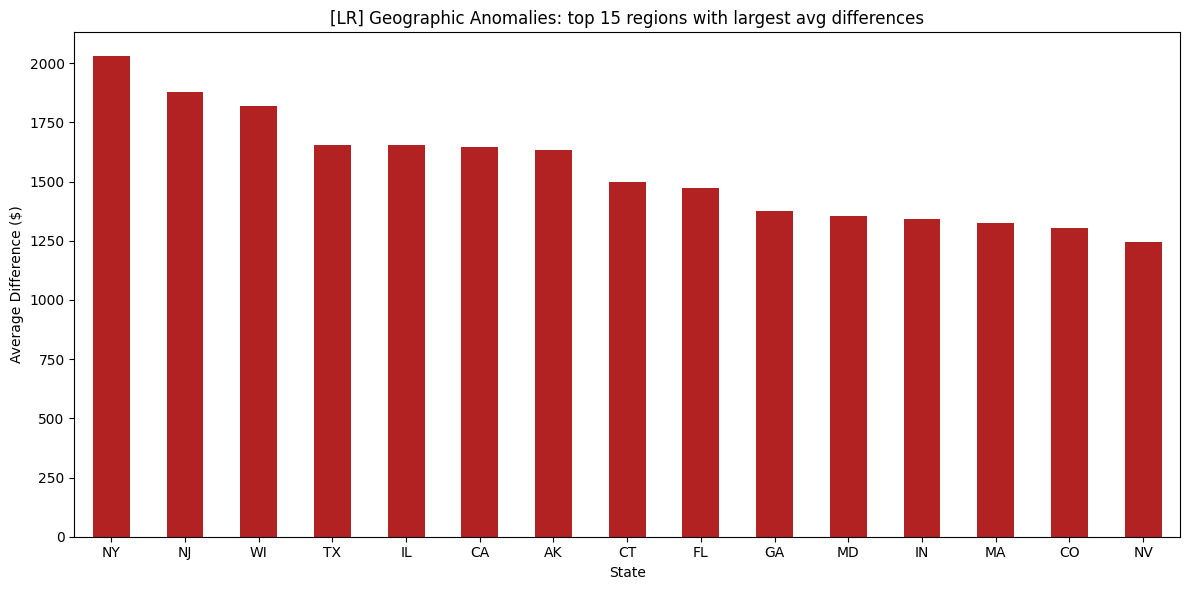

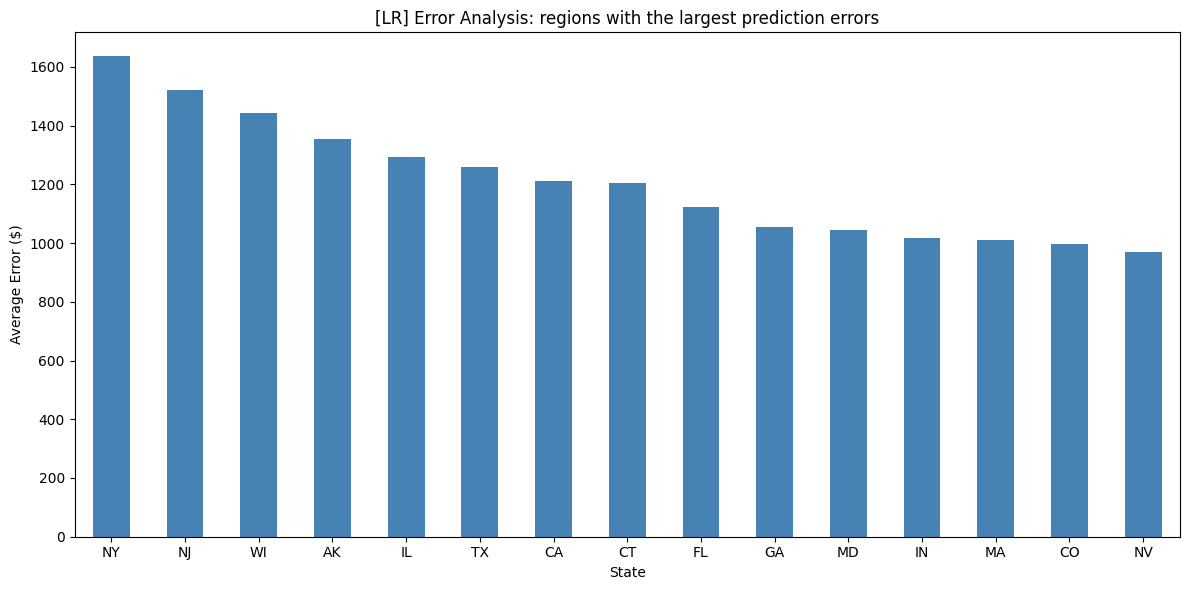

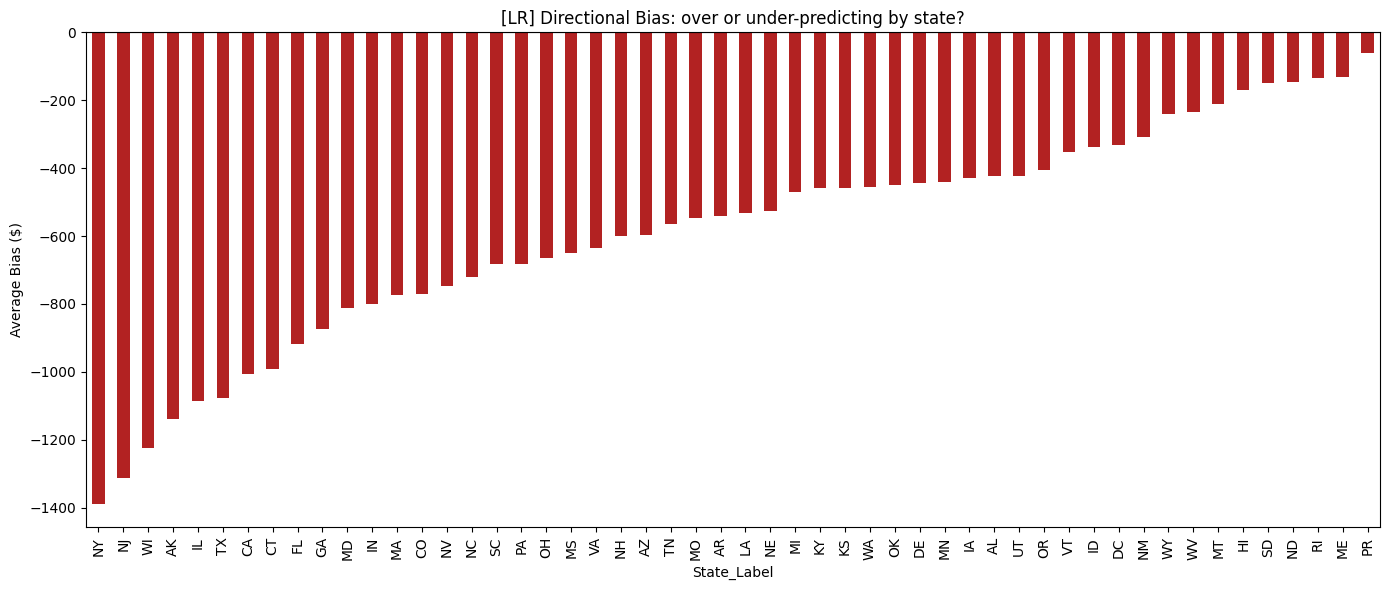

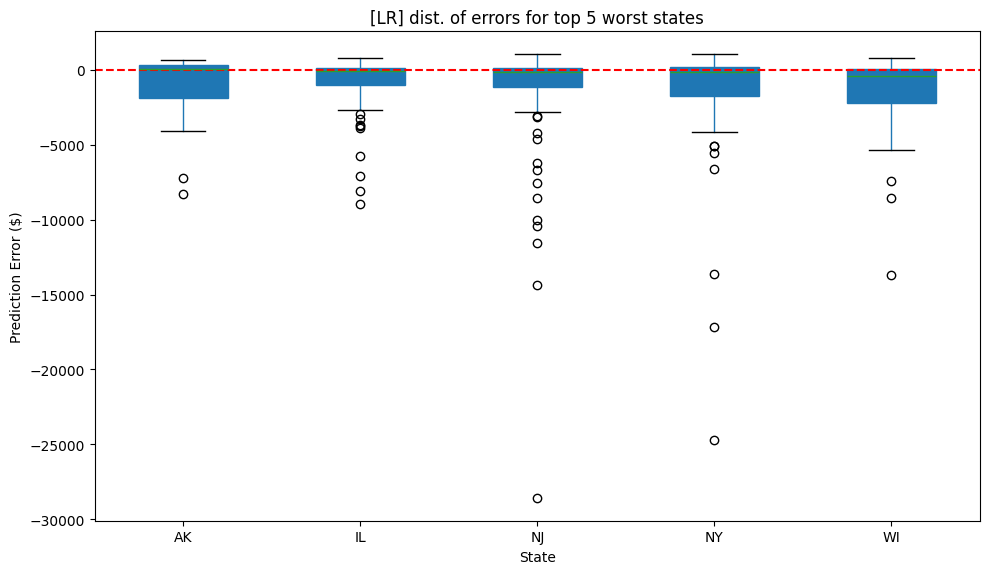

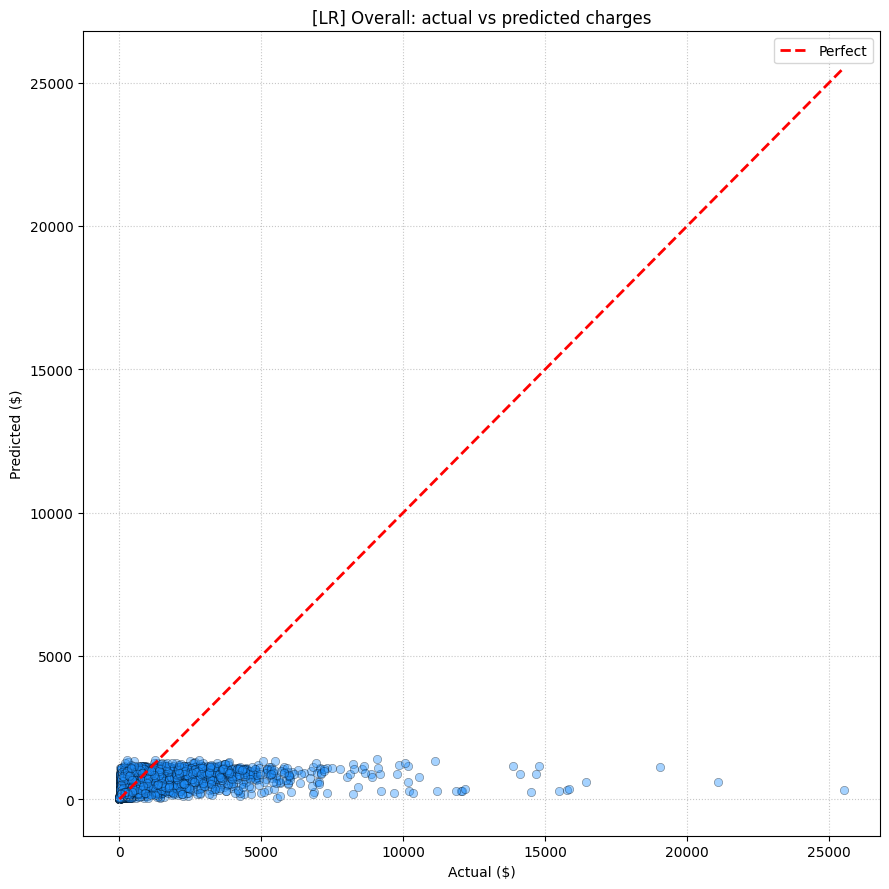

In [33]:
lr=LinearRegression(featuresCol='Features_Col',
                    labelCol='Avg_Sbmtd_Chrg',
                    maxIter=50,
                    regParam=0.1,
                    elasticNetParam=0.5)

lr_model,lr_preds=spark_model_faster(lr,test_features,"models/lr_model")

lr_preds = lr_preds.withColumn("prediction_original",expm1("prediction")
)
lr_preds = prep_predictions(lr_preds)

plot_geographic_anomalies(lr_preds, "LR")
err_df = plot_error_analysis(lr_preds, "LR")
plot_directional_bias(err_df, "LR")
plot_error_distribution(lr_preds, err_df, "LR")
plot_actual_vs_predicted(lr_preds, "LR")

## RF

Loading existing model...


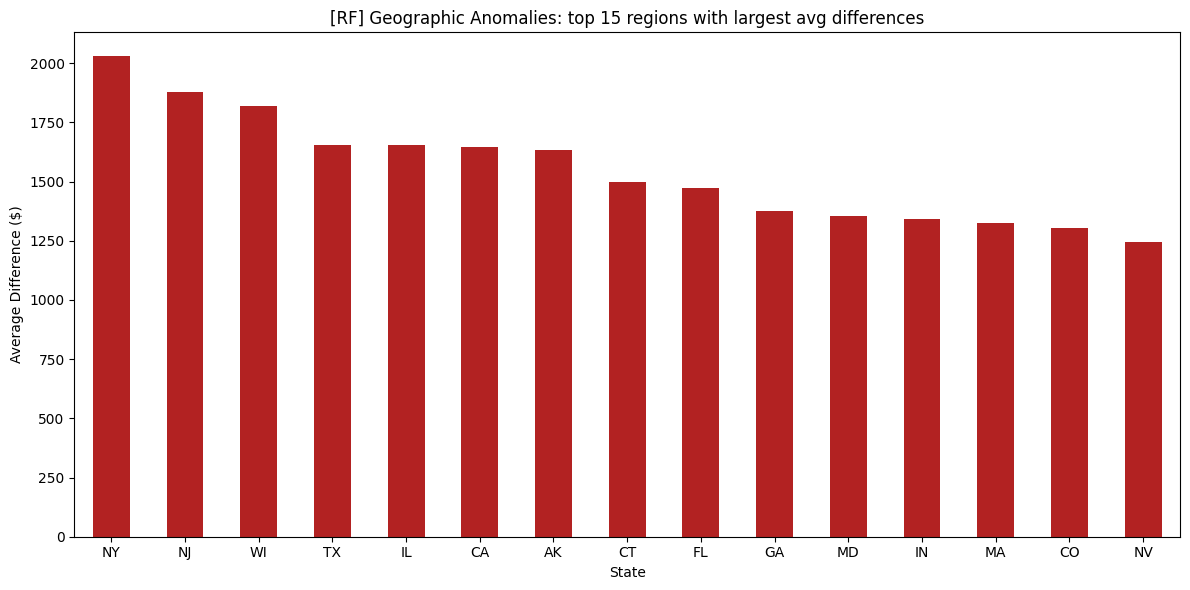

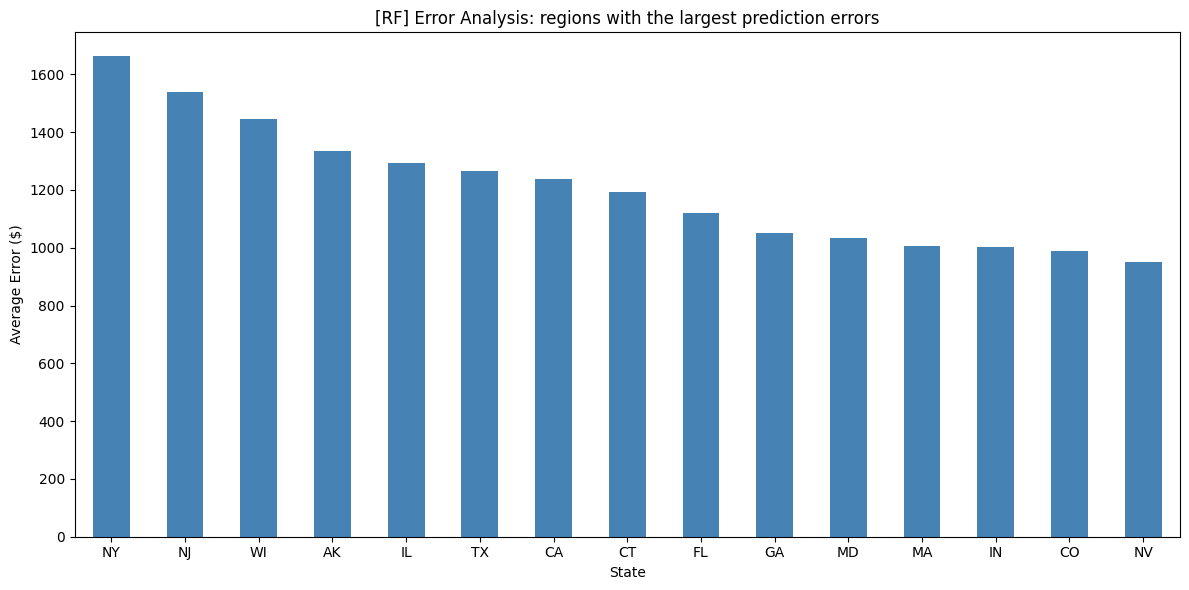

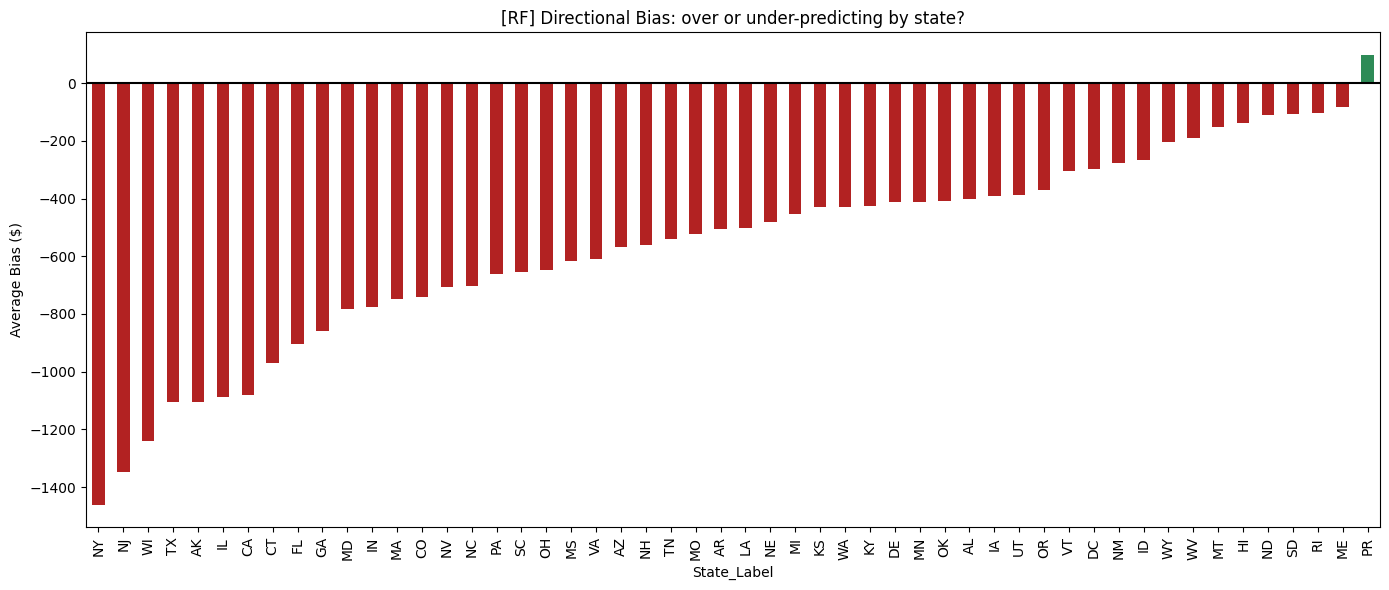

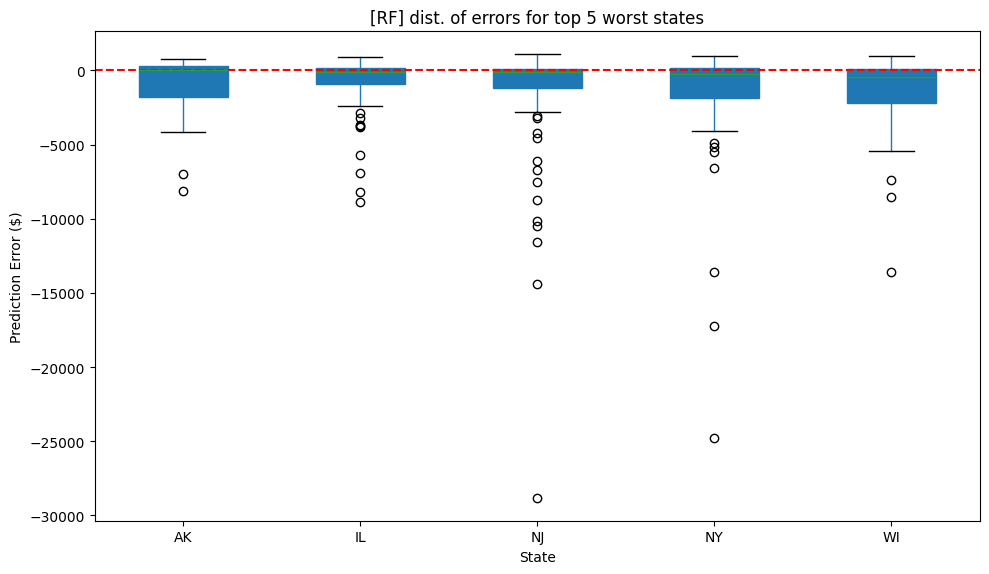

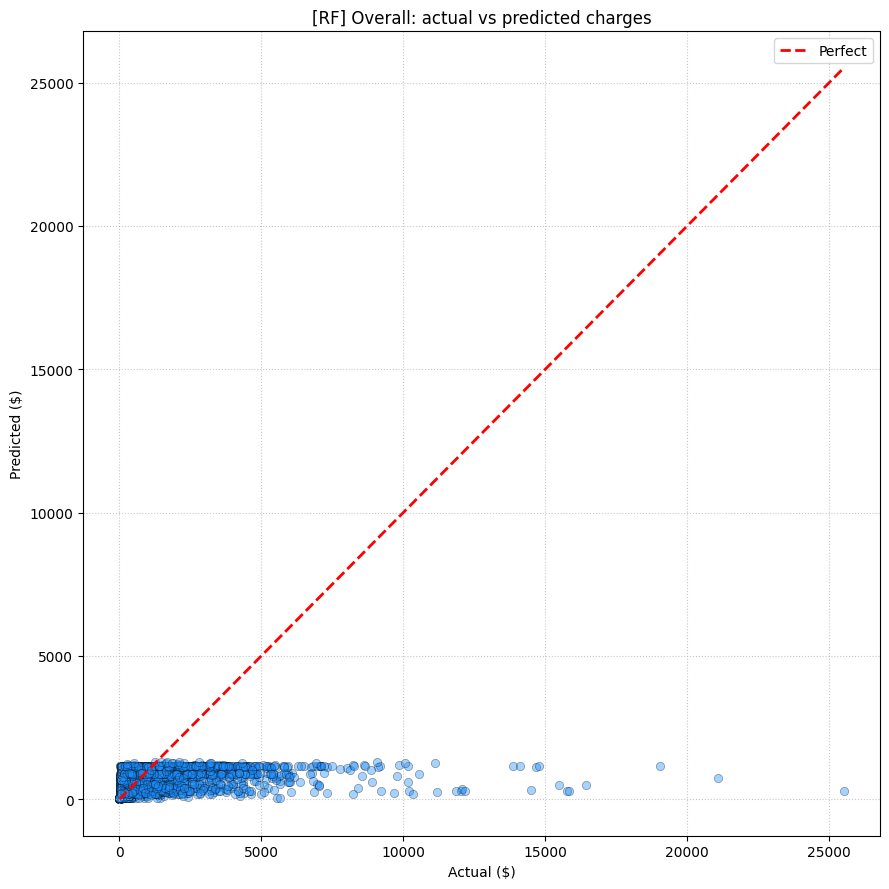

In [34]:
rf = RandomForestRegressor(featuresCol="Features_Col", labelCol="Avg_Sbmtd_Chrg")

rf_model,rf_preds=spark_model_faster(rf,test_features,"models/rf_model")

rf_preds = rf_preds.withColumn("prediction_original",expm1("prediction")
)
rf_preds = prep_predictions(rf_preds)

plot_geographic_anomalies(rf_preds, "RF")
rf_err_df = plot_error_analysis(rf_preds, "RF")
plot_directional_bias(rf_err_df, "RF")
plot_error_distribution(rf_preds, rf_err_df, "RF")
plot_actual_vs_predicted(rf_preds, "RF")

## GBT

Loading existing model...


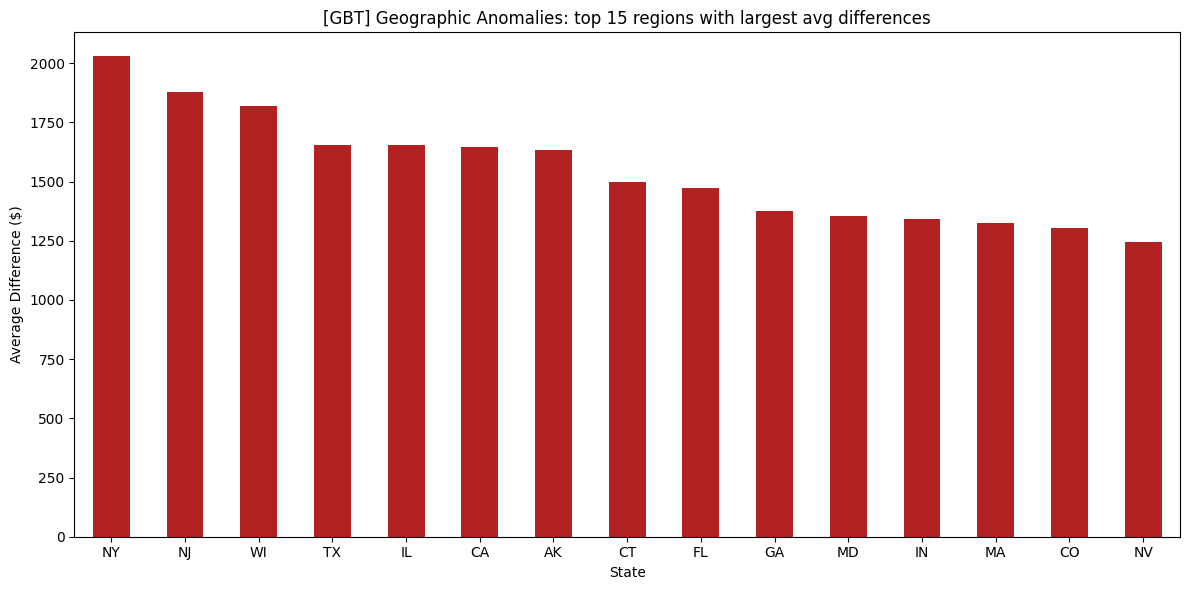

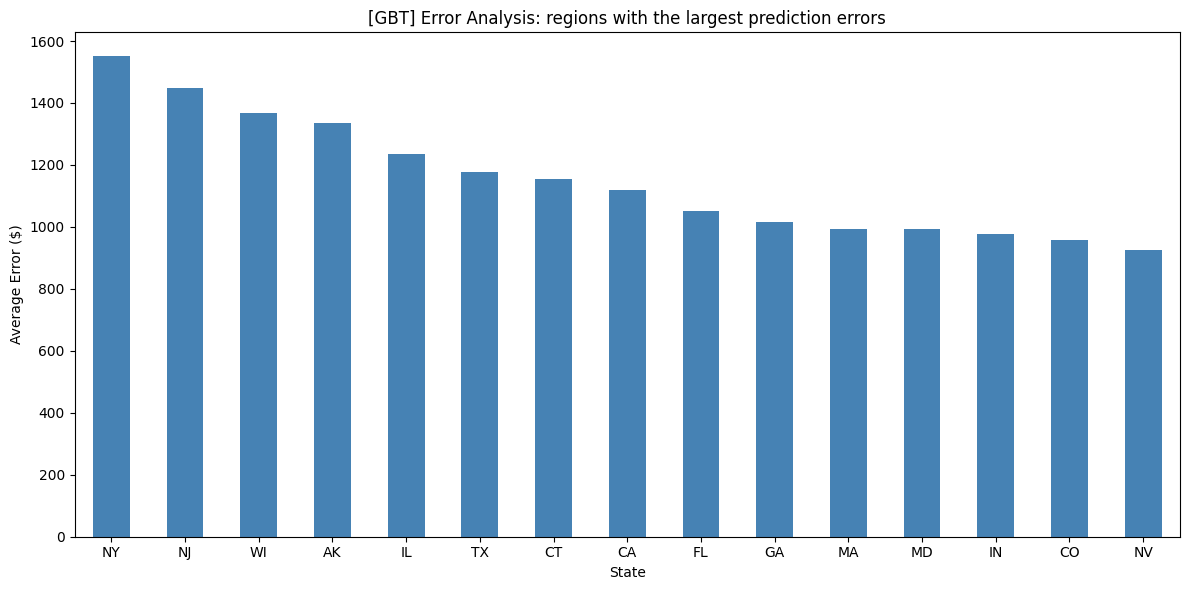

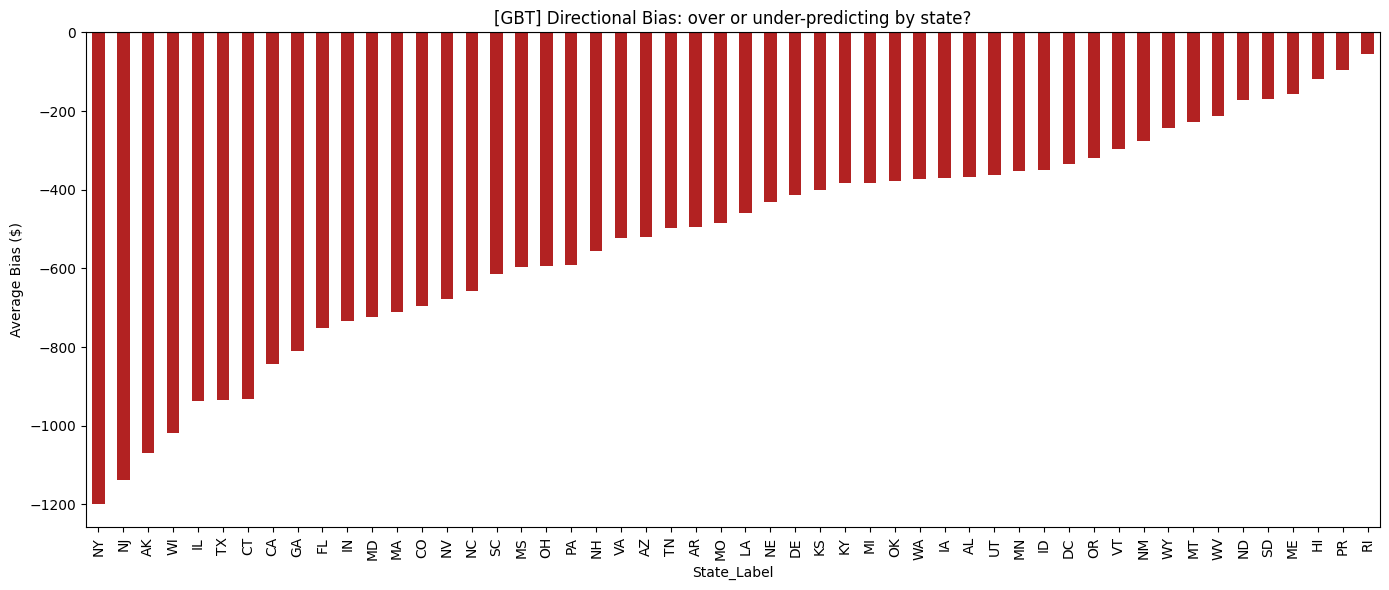

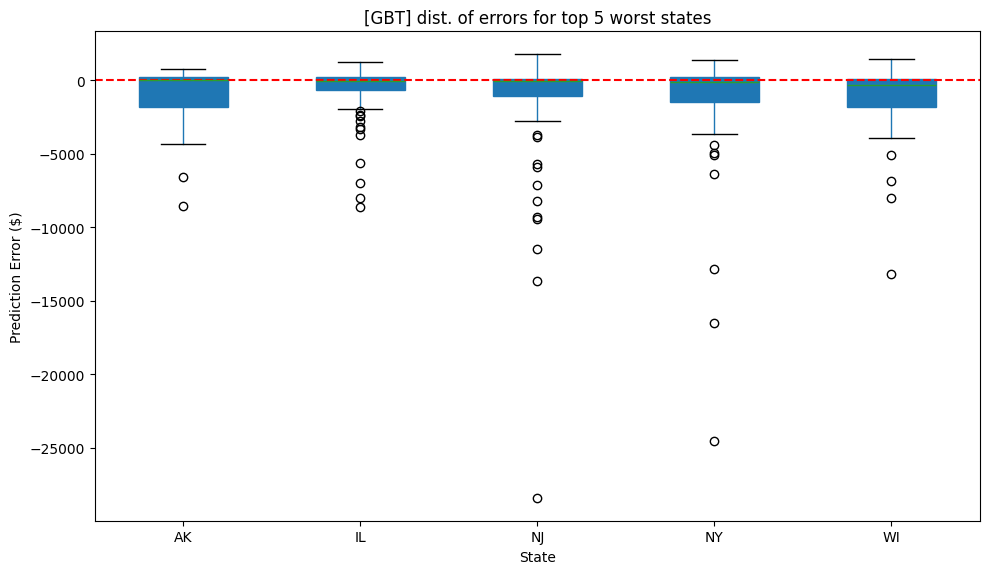

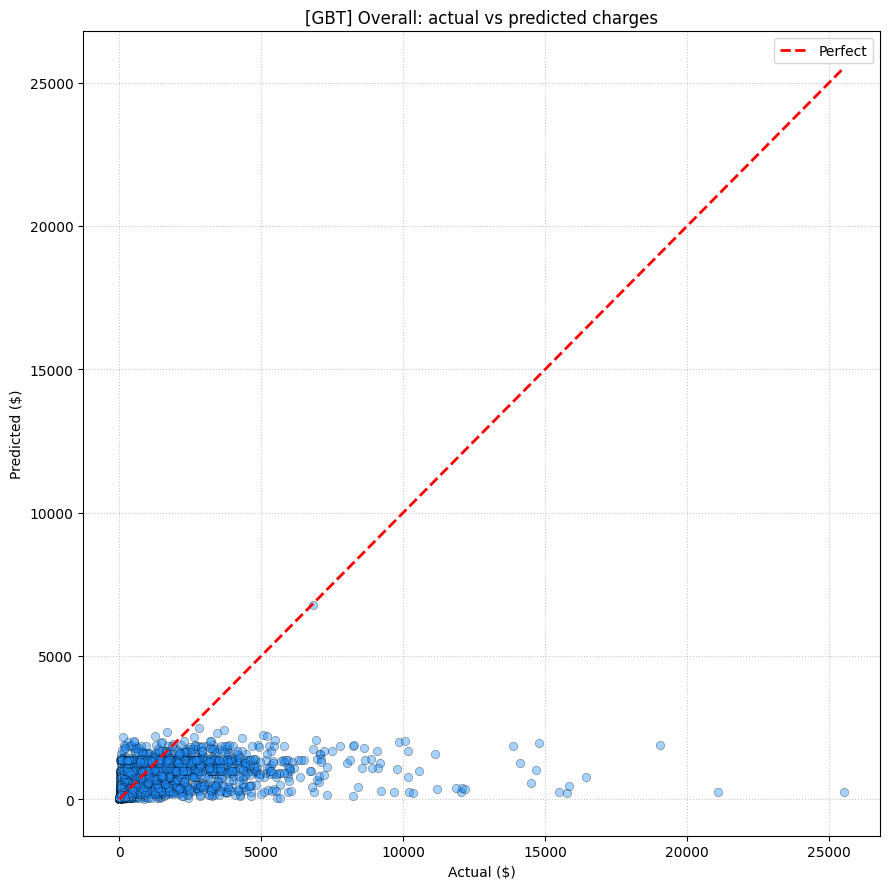

In [35]:
gbt = GBTRegressor(
    featuresCol="Features_Col",
    labelCol="Avg_Sbmtd_Chrg",
    seed=42,
     maxIter=20,
     maxDepth=5,
     stepSize=0.1,subsamplingRate=0.8
)

gbt_model, gbt_preds = spark_model_faster(gbt, test_features,'models/gbt_model')

gbt_preds = gbt_preds.withColumn("prediction_original",expm1("prediction")
)
gbt_preds = prep_predictions(gbt_preds)

plot_geographic_anomalies(gbt_preds, "GBT")
gbt_err_df = plot_error_analysis(gbt_preds, "GBT")
plot_directional_bias(gbt_err_df, "GBT")
plot_error_distribution(gbt_preds, gbt_err_df, "GBT")
plot_actual_vs_predicted(gbt_preds, "GBT")